<a href="https://colab.research.google.com/github/luccasnn/previsao_series-temporais/blob/main/previsao_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

# verifica gpu
print("GPU:", tf.config.list_physical_devices('GPU'))

# dados reais de preço do bitcoin via yahoo finance
!pip install yfinance -q
import yfinance as yf

btc = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01', progress=False)
df = btc[['Close']].copy()

print("\nShape:", df.shape)
print("\nPrimeiros registros:")
print(df.head())
print("\nÚltimos registros:")
print(df.tail())

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Shape: (1461, 1)

Primeiros registros:
Price             Close
Ticker          BTC-USD
Date                   
2020-01-01  7200.174316
2020-01-02  6985.470215
2020-01-03  7344.884277
2020-01-04  7410.656738
2020-01-05  7411.317383

Últimos registros:
Price              Close
Ticker           BTC-USD
Date                    
2023-12-27  43442.855469
2023-12-28  42627.855469
2023-12-29  42099.402344
2023-12-30  42156.902344
2023-12-31  42265.187500


/tmp/ipykernel_1351/148580885.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2020-01-01', end='2024-01-01', progress=False)


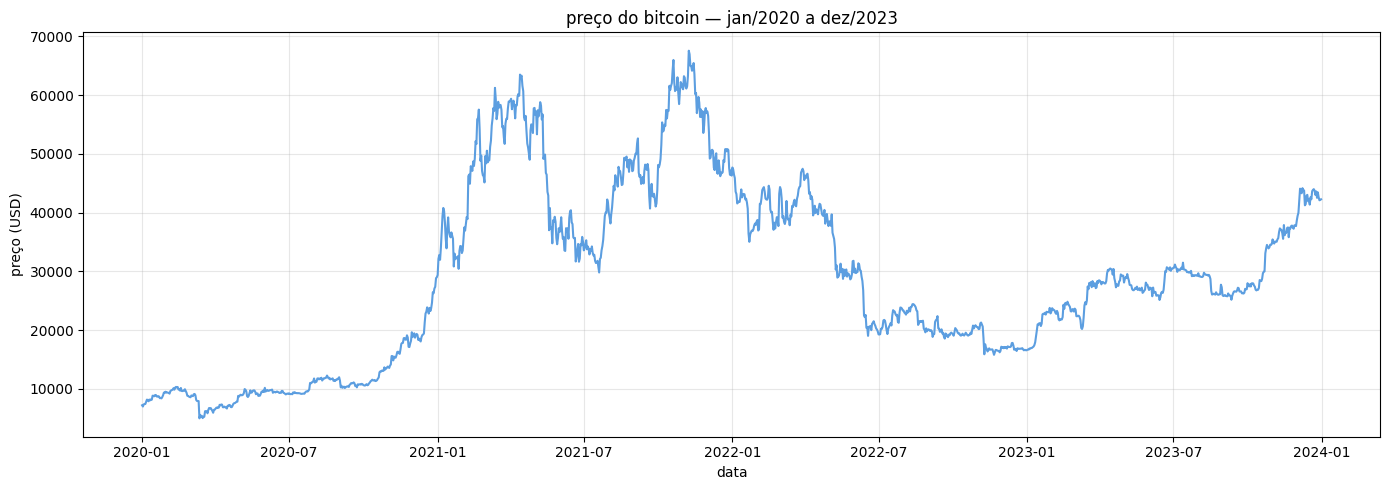

Treino: (1120, 60, 1)
Teste: (281, 60, 1)


In [7]:
# visualiza série histórica
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='#5c9ee0', linewidth=1.5)
plt.title('preço do bitcoin — jan/2020 a dez/2023')
plt.xlabel('data')
plt.ylabel('preço (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('btc_historico.png', dpi=150, bbox_inches='tight')
plt.show()

# normaliza entre 0 e 1
scaler = MinMaxScaler()
dados_scaled = scaler.fit_transform(df[['Close']])

# cria sequências — usa 60 dias pra prever o próximo
def criar_sequencias(dados, janela=60):
    X, y = [], []
    for i in range(janela, len(dados)):
        X.append(dados[i-janela:i, 0])
        y.append(dados[i, 0])
    return np.array(X), np.array(y)

X, y = criar_sequencias(dados_scaled)
X = X.reshape(X.shape[0], X.shape[1], 1)

# split treino/teste
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

In [8]:
# arquitetura lstm
modelo = models.Sequential([
    layers.LSTM(50, return_sequences=True, input_shape=(60, 1)),
    layers.Dropout(0.2),
    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(25, activation='relu'),
    layers.Dense(1)
])

modelo.compile(optimizer='adam', loss='mse')
modelo.summary()

# treino
historico = modelo.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0705 - val_loss: 0.0034
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0087 - val_loss: 0.0016
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0063 - val_loss: 7.0271e-04
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 9.3377e-04
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - val_loss: 7.1940e-04
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049 - val_loss: 6.3845e-04
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - val_loss: 6.3045e-04
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0038 - val_loss: 7.9043e-04
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0035 - val_loss: 7.2290e-04
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034 - val_loss: 7.2491e-04
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - val_loss: 6.4362e-04
Epoch 12/20
32/32 ━━━━━━━━

MAE:  $898
RMSE: $1,272


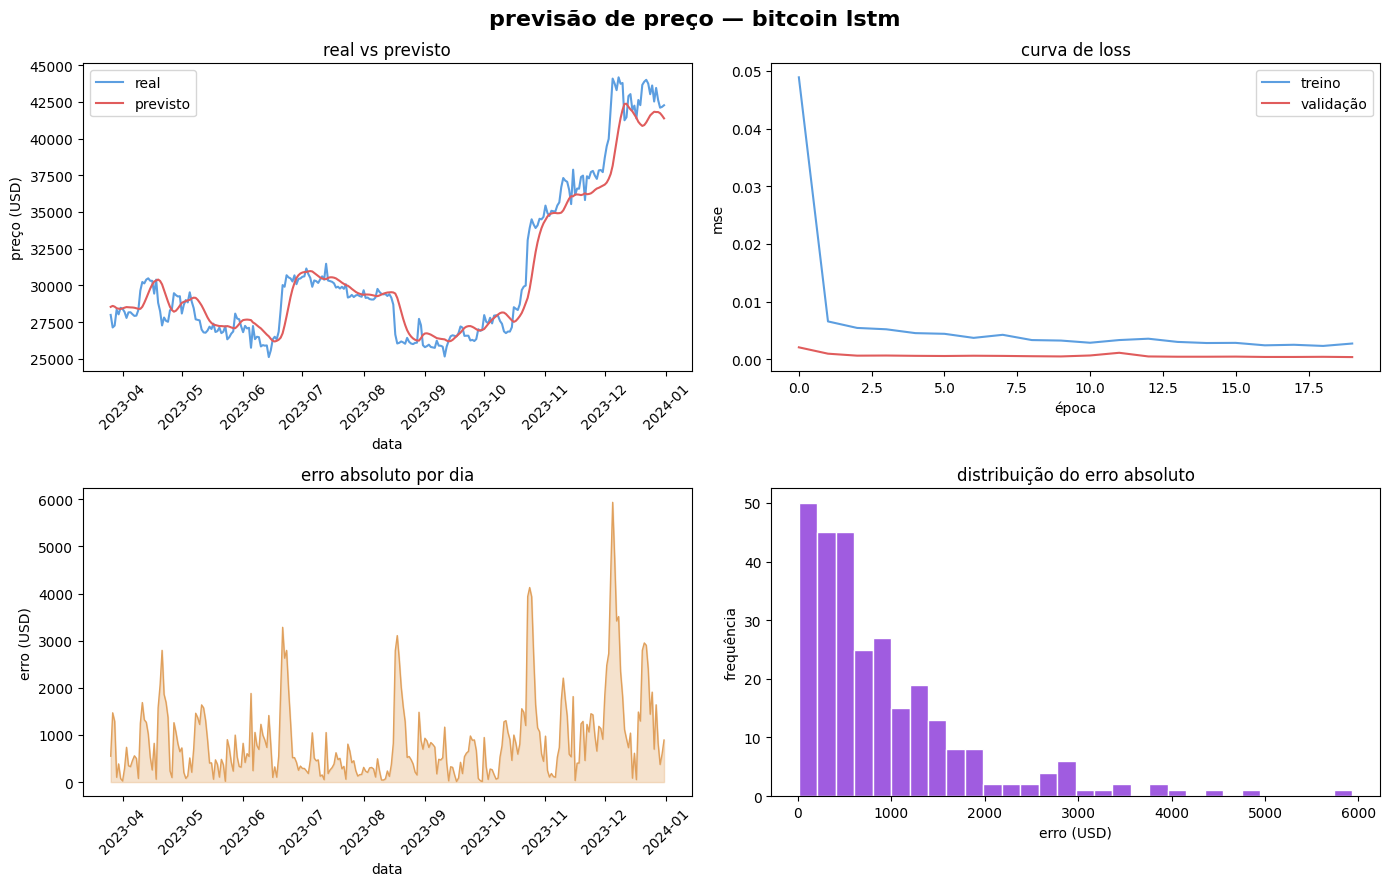

In [ ]:
# previsões
y_pred = modelo.predict(X_test, verbose=0)

# volta pra escala original
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred)

# datas do conjunto de teste
datas_teste = df.index[split + 60:]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('previsão de preço — bitcoin lstm', fontsize=16, fontweight='bold')

# real vs previsto
axes[0, 0].plot(datas_teste, y_test_real, color='#5c9ee0', label='real', linewidth=1.5)
axes[0, 0].plot(datas_teste, y_pred_real, color='#e05c5c', label='previsto', linewidth=1.5)
axes[0, 0].set_title('real vs previsto')
axes[0, 0].set_xlabel('data')
axes[0, 0].set_ylabel('preço (USD)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# curva de loss
axes[0, 1].plot(historico.history['loss'], color='#5c9ee0', label='treino')
axes[0, 1].plot(historico.history['val_loss'], color='#e05c5c', label='validação')
axes[0, 1].set_title('curva de loss')
axes[0, 1].set_xlabel('época')
axes[0, 1].set_ylabel('mse')
axes[0, 1].legend()

# erro por previsão
erro = np.abs(y_test_real - y_pred_real).flatten()
axes[1, 0].plot(datas_teste, erro, color='#e0a05c', linewidth=1)
axes[1, 0].fill_between(datas_teste, erro, alpha=0.3, color='#e0a05c')
axes[1, 0].set_title('erro absoluto por dia')
axes[1, 0].set_xlabel('data')
axes[1, 0].set_ylabel('erro (USD)')
axes[1, 0].tick_params(axis='x', rotation=45)

# distribuição do erro
axes[1, 1].hist(erro, bins=30, color='#a05ce0', edgecolor='white')
axes[1, 1].set_title('distribuição do erro absoluto')
axes[1, 1].set_xlabel('erro (USD)')
axes[1, 1].set_ylabel('frequência')

# métricas
mae = np.mean(erro)
rmse = np.sqrt(np.mean(erro**2))
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")

plt.tight_layout()
plt.savefig('previsao_btc.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from google.colab import files
files.download('btc_historico.png')
files.download('previsao_btc.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>